# Time Series Modeling (SARIMA)

This notebook covers:
- Step 3: Stationarity checks (ACF/PACF, ADF)
- Step 4: Train/test split and auto-ARIMA
- Step 5: Model diagnostics (RMSE/MAPE, Ljung-Box)
- Step 6: Forecasting and inverse transform


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima

plt.style.use("seaborn-v0_8")

In [2]:
data_path = Path("ev_market_share.csv")

if data_path.exists():
    monthly = pd.read_csv(data_path, parse_dates=["year_month"], index_col="year_month")
else:
    raw = pd.read_csv("China Automobile Sales Data.csv")
    raw["year_month"] = pd.to_datetime(raw["year_month"], errors="coerce")
    raw = raw.dropna(subset=["year_month"])
    monthly = (
        raw.groupby("year_month", as_index=False)[["EV_Sales", "Total_Sales"]]
        .sum()
        .sort_values("year_month")
    )
    monthly["EV_Market_Share"] = monthly["EV_Sales"] / monthly["Total_Sales"]
    monthly = monthly.set_index("year_month")

if "EV_Market_Share_Logit" not in monthly.columns:
    epsilon = 1e-6
    share = monthly["EV_Market_Share"].clip(epsilon, 1 - epsilon)
    monthly["EV_Market_Share_Logit"] = np.log(share / (1 - share))

monthly.head()

,Total_Sales,EV_Sales,EV_Market_Share,EV_Market_Share_Logit
year_month,,,,
2018-01-01,2436495,24480,0.010047,-4.590361
2018-02-01,1469679,23449,0.015955,-4.121888
2018-03-01,2144088,42745,0.019936,-3.895080
2018-04-01,1881043,51110,0.027171,-3.578054
2018-05-01,1887345,60565,0.032090,-3.406593


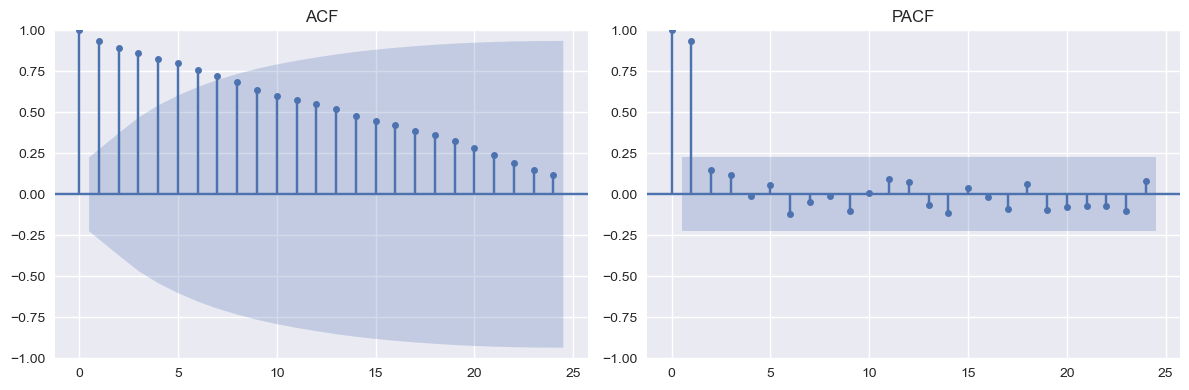

d=0 ADF p-value: 0.9206
d=1 ADF p-value: 0.2455
d=2 ADF p-value: 0.0245


In [3]:
y = monthly["EV_Market_Share_Logit"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, ax=axes[0], lags=24)
plot_pacf(y, ax=axes[1], lags=24, method="ywm")
axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()


def adf_until_stationary(series, max_diff=2):
    current = series.copy()
    d = 0
    while d <= max_diff:
        result = adfuller(current.dropna(), autolag="AIC")
        print(f"d={d} ADF p-value: {result[1]:.4f}")
        if result[1] < 0.05:
            return current, d
        current = current.diff().dropna()
        d += 1
    return current, d


y_stationary, d = adf_until_stationary(y, max_diff=2)

In [4]:
train = y.iloc[:64]
test = y.iloc[64:]

model = auto_arima(
    train,
    seasonal=True,
    m=12,
    d=d,
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[12]             : AIC=inf, Time=0.57 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=66.033, Time=0.05 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=44.303, Time=0.04 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=inf, Time=0.14 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=42.387, Time=0.01 sec
 ARIMA(1,2,0)(0,0,1)[12]             : AIC=44.317, Time=0.03 sec
 ARIMA(1,2,0)(1,0,1)[12]             : AIC=inf, Time=0.17 sec
 ARIMA(2,2,0)(0,0,0)[12]             : AIC=14.189, Time=0.04 sec
 ARIMA(2,2,0)(1,0,0)[12]             : AIC=16.002, Time=0.05 sec
 ARIMA(2,2,0)(0,0,1)[12]             : AIC=15.992, Time=0.06 sec
 ARIMA(2,2,0)(1,0,1)[12]             : AIC=inf, Time=0.34 sec
 ARIMA(3,2,0)(0,0,0)[12]             : AIC=15.091, Time=0.03 sec
 ARIMA(2,2,1)(0,0,0)[12]             : AIC=7.386, Time=0.05 sec
 ARIMA(2,2,1)(1,0,0)[12]             : AIC=9.384, Time=0.09 sec
 ARIMA(2,2,1)(0,0,1)[12]             : AIC=9.384, Time=0.12 s

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   64
Model:               SARIMAX(2, 2, 1)   Log Likelihood                   0.307
Date:                Thu, 07 May 2026   AIC                              7.386
Time:                        22:12:26   BIC                             15.895
Sample:                    01-01-2018   HQIC                            10.727
                         - 04-01-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5059      0.113     -4.464      0.000      -0.728      -0.284
ar.L2         -0.3227      0.157     -2.058      0.040      -0.630      -0.015
ma.L1         -0.8039      0.102     -7.868      0.000      -1.004      -0.604
sigma2         0.0558      0.007      7.883      0.000       0.042       0.070
===================================================================================
Ljung-Box (L1) (Q):                   0.10   Jarque-Bera (JB):                13.44
Prob(Q):                              0.75   Prob(JB):                         0.00
Heteroskedasticity (H):               0.26   Skew:                            -0.75
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

n_test = len(test)
pred_test, test_conf = model.predict(n_periods=n_test, return_conf_int=True)
pred_test = pd.Series(pred_test, index=test.index)

actual_share = monthly["EV_Market_Share"].loc[test.index]
pred_share = sigmoid(pred_test)

rmse = np.sqrt(mean_squared_error(actual_share, pred_share))
mape = (
    np.mean(np.abs((actual_share - pred_share) / actual_share.replace(0, np.nan))) * 100
)

print(f"RMSE (share): {rmse:.6f}")
print(f"MAPE (share): {mape:.2f}%")

resid = model.arima_res_.resid
lb = acorr_ljungbox(resid, lags=[12], return_df=True)

lb

RMSE (share): 0.050730
MAPE (share): 12.74%


,lb_stat,lb_pvalue
12,12.962984,0.371737


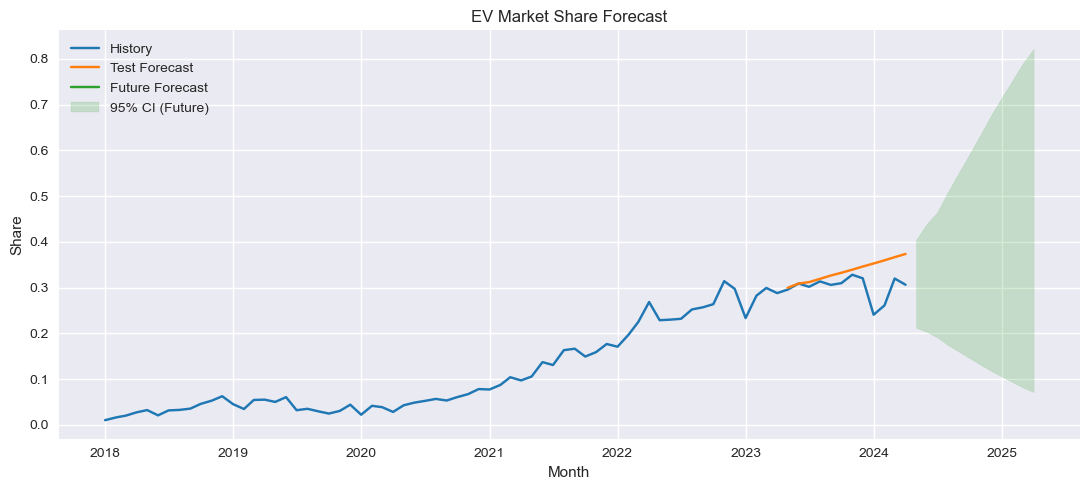

In [6]:
forecast_horizon = 12

future_pred, future_conf = model.predict(
    n_periods=forecast_horizon,
    return_conf_int=True,
)

future_index = pd.date_range(
    start=monthly.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS",
)

future_pred = pd.Series(future_pred, index=future_index)
future_conf = pd.DataFrame(future_conf, index=future_index, columns=["lower", "upper"])

future_share = sigmoid(future_pred)
future_lower = sigmoid(future_conf["lower"])
future_upper = sigmoid(future_conf["upper"])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly["EV_Market_Share"], label="History", color="#1f77b4")
ax.plot(test.index, pred_share, label="Test Forecast", color="#ff7f0e")
ax.plot(future_index, future_share, label="Future Forecast", color="#2ca02c")

ax.fill_between(
    future_index,
    future_lower,
    future_upper,
    color="#2ca02c",
    alpha=0.2,
    label="95% CI (Future)",
)

ax.set_title("EV Market Share Forecast")
ax.set_ylabel("Share")
ax.set_xlabel("Month")
ax.legend()
plt.tight_layout()
plt.show()